## Intervention on Restatement during GPT-OSS' Vanilla Reasoning

In [1]:
%load_ext autoreload
%autoreload 2

### Overview

Combines activation patching of a restated number with residual-stream steering, sweeping the patched layer against the steering layer, to test whether steering can suppress or amplify the intervention's causal effect.

### Set-up

In [ ]:
import torch
import gc
import pandas as pd
from tqdm import tqdm
import random

import sys
sys.path.append("src")
import _util
import _dataset
from _intervention import prepare_batch_multitoken_intervention, batch_intervene, prepare_batch_multitoken_steering

In [3]:
_util.print_GPU_availbility()

CUDA is available: True
Available devices:
  GPU 0: NVIDIA GeForce RTX 3090
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |
|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |  

In [4]:
model_type = "GPT-OSS"
model, tokenizer = _util.load_OSS()

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

## Prompt Templates

Defines the prompt templates and builds the factual/counterfactual addition dataset used for patching below.

In [5]:
system_prompt = '''<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-06-28

Reasoning: high

# Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|>'''

user_question = '''<|start|>user<|message|>What is {num1}+{num2}?<|end|>'''

reasoning = '''<|start|>assistant<|channel|>analysis<|message|>The user asks: "What is {num1}+{num2}?" This is a simple arithmetic question. {num1}+{num2}='''

reasoning = '''<|start|>assistant<|channel|>analysis<|message|>We need to answer the question: "What is {num1}+{num2}?" The answer is '''

In [6]:
random.seed(42)

add_ds = _dataset.create_h2_dataset(num_digits=2, num_samples=256)

In [7]:
def get_prompt(num1, num2):
    return (system_prompt + user_question + reasoning).format(num1=num1, num2=num2)

In [8]:
prompt = get_prompt(add_ds[0]["base_1_num"], add_ds[0]["base_2_num"])
print(prompt)

<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-06-28

Reasoning: high

# Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|><|start|>user<|message|>What is 20+54?<|end|><|start|>assistant<|channel|>analysis<|message|>We need to answer the question: "What is 20+54?" The answer is 


In [9]:
patch_ds = []
for add_ds_entry in add_ds:
    patch_ds.append([add_ds_entry["base_1_num"], add_ds_entry["base_2_num"], add_ds_entry["source_1_num"], add_ds_entry["source_2_num"], add_ds_entry["base_sum"], add_ds_entry["source_sum"], get_prompt(add_ds_entry["base_1_num"], add_ds_entry["base_2_num"]), get_prompt(add_ds_entry["source_1_num"], add_ds_entry["source_2_num"])])

# Convert patch_ds to pandas DataFrame
patch_ds = pd.DataFrame(patch_ds, columns=['base_1_num', 'base_2_num', 'source_1_num', 'source_2_num', 'base_sum', 'source_sum', 'base_prompt', 'source_prompt'])

In [ ]:
# for i, row in patch_ds.iterrows():
#     tokens = tokenizer(row["base_prompt"], return_tensors="pt").to(model.device)
#     print(list(enumerate(tokenizer.convert_ids_to_tokens(tokens["input_ids"][0]))))
#     print(len(tokens["input_ids"][0]))


[(0, '<|start|>'), (1, 'system'), (2, '<|message|>'), (3, 'You'), (4, 'Ġare'), (5, 'ĠChat'), (6, 'GPT'), (7, ','), (8, 'Ġa'), (9, 'Ġlarge'), (10, 'Ġlanguage'), (11, 'Ġmodel'), (12, 'Ġtrained'), (13, 'Ġby'), (14, 'ĠOpen'), (15, 'AI'), (16, '.Ċ'), (17, 'Knowledge'), (18, 'Ġcutoff'), (19, ':'), (20, 'Ġ'), (21, '202'), (22, '4'), (23, '-'), (24, '06'), (25, 'Ċ'), (26, 'Current'), (27, 'Ġdate'), (28, ':'), (29, 'Ġ'), (30, '202'), (31, '5'), (32, '-'), (33, '06'), (34, '-'), (35, '28'), (36, 'ĊĊ'), (37, 'Reason'), (38, 'ing'), (39, ':'), (40, 'Ġhigh'), (41, 'ĊĊ'), (42, '#'), (43, 'ĠValid'), (44, 'Ġchannels'), (45, ':'), (46, 'Ġanalysis'), (47, ','), (48, 'Ġcommentary'), (49, ','), (50, 'Ġfinal'), (51, '.'), (52, 'ĠChannel'), (53, 'Ġmust'), (54, 'Ġbe'), (55, 'Ġincluded'), (56, 'Ġfor'), (57, 'Ġevery'), (58, 'Ġmessage'), (59, '.'), (60, '<|end|>'), (61, '<|start|>'), (62, 'user'), (63, '<|message|>'), (64, 'What'), (65, 'Ġis'), (66, 'Ġ'), (67, '20'), (68, '+'), (69, '54'), (70, '?'), (71, '<|en

In [11]:
# # Load steering vectors
# steering_vectors = torch.load("experiments/activation_intervention/steering_vectors_gpt-oss-20b.pt")
# print(steering_vectors.keys())
# backtracking_vectors = steering_vectors["backtracking"]["mean"]
# uncertainty_vectors = steering_vectors["uncertainty-estimation"]["mean"]
# initializing_vectors = steering_vectors["initializing"]["mean"]
# deduction_vectors = steering_vectors["deduction"]["mean"]
# for backtracking_vector, uncertainty_vector, initializing_vector, deduction_vector in zip(backtracking_vectors, uncertainty_vectors, initializing_vectors, deduction_vectors):
#     print(f"backtracking & uncertainty: {torch.nn.functional.cosine_similarity(backtracking_vector, uncertainty_vector, dim=0)}")
#     print(f"backtracking & initializing: {torch.nn.functional.cosine_similarity(backtracking_vector, initializing_vector, dim=0)}")
#     print(f"uncertainty & initializing: {torch.nn.functional.cosine_similarity(uncertainty_vector, initializing_vector, dim=0)}")
#     print(f"deduction & backtracking: {torch.nn.functional.cosine_similarity(deduction_vector, backtracking_vector, dim=0)}")
#     print(f"deduction & uncertainty: {torch.nn.functional.cosine_similarity(deduction_vector, uncertainty_vector, dim=0)}")
#     print(f"deduction & initializing: {torch.nn.functional.cosine_similarity(deduction_vector, initializing_vector, dim=0)}")


In [12]:
steering_vectors = torch.load("experiments/activation_intervention/steering_vectors_gpt-oss-20b.pt")
backtracking_vectors = steering_vectors["backtracking"]["mean"]

### Intervention

Sweeps the patched layer against the steering layer, applying an activation patch together with a steering hook at each combination, and records whether the generated answer is factual or counterfactual.

In [23]:
tok_pos_list = [90]

header = ['intervene_layer', 'steering_layer'] + list(patch_ds.columns) + ['generated_text', 'is_factual', 'is_counterfactual']
filepath = _util.create_csv_file(f"experiments/activation_intervention/output/{model_type}/vanilla_steering", f"answer_prediction_positive.csv", header, overwrite=True)

batch_size = 24
for intervene_layer in range(0,20,4):
    print(f"Intervening on layer {intervene_layer}")
    for steering_layer in range(intervene_layer,20,4):
        print(f"Steering on layer {steering_layer}")
        for i in tqdm(range(0, len(patch_ds), batch_size)):
            torch.cuda.empty_cache()
            gc.collect()
            batch_rows = patch_ds.iloc[i:i+batch_size]

            tokens, _, intervene_hook = prepare_batch_multitoken_intervention(model, tokenizer, intervene_layer, tok_pos_list, batch_rows['base_prompt'].tolist(), batch_rows['source_prompt'].tolist())
            input_length = tokens["input_ids"].shape[1]

            steering_tokens, steering_hook = prepare_batch_multitoken_steering(model, tokenizer, steering_layer, [95], batch_rows['base_prompt'].tolist(), backtracking_vectors[steering_layer])
            assert torch.equal(tokens['input_ids'], steering_tokens['input_ids'])

            for j in range(1):
                # attention_freeze_hooks = get_attention_freeze_hooks(model, tokens)
                with torch.no_grad():
                    output = batch_intervene(model, tokens["input_ids"], [intervene_hook, steering_hook], attention_mask=tokens["attention_mask"]) # attention_freeze_hooks + 
                pred_toks = output.logits[:,-1,:].argmax(dim=-1)
                tokens["input_ids"] = torch.cat([tokens["input_ids"], pred_toks.unsqueeze(-1)], dim=1)
                del output
            
            for j, (_, row) in enumerate(batch_rows.iterrows()):
                generated_text = tokenizer.decode(tokens["input_ids"][j,input_length:]).replace(tokenizer.pad_token[-1], "")
                is_factual = str(row["base_sum"]) in generated_text
                is_counterfactual = str(row["source_sum"]) in generated_text
                _util.write_to_csv(filepath, [intervene_layer, steering_layer] + row.to_list() + [generated_text, is_factual, is_counterfactual])

            del tokens, intervene_hook, steering_hook
            torch.cuda.empty_cache()
            gc.collect()

Intervening on layer 0
Steering on layer 0


100%|████████████████████████████████████████████████████████████████████| 11/11 [00:49<00:00,  4.52s/it]


Steering on layer 4


100%|████████████████████████████████████████████████████████████████████| 11/11 [00:49<00:00,  4.53s/it]


Steering on layer 8


...

100%|████████████████████████████████████████████████████████████████████| 11/11 [00:50<00:00,  4.55s/it]


Steering on layer 16


100%|████████████████████████████████████████████████████████████████████| 11/11 [00:49<00:00,  4.54s/it]


Intervening on layer 16
Steering on layer 16


100%|████████████████████████████████████████████████████████████████████| 11/11 [00:49<00:00,  4.53s/it]


## Results
Steering the same layer as the intervention:  
* Positive: slightly less intervention effect
* Negative: significantly less intervention effect

Steering on layer 16:  
* Positive: No intervention effect
* Negative: Full intervention effect

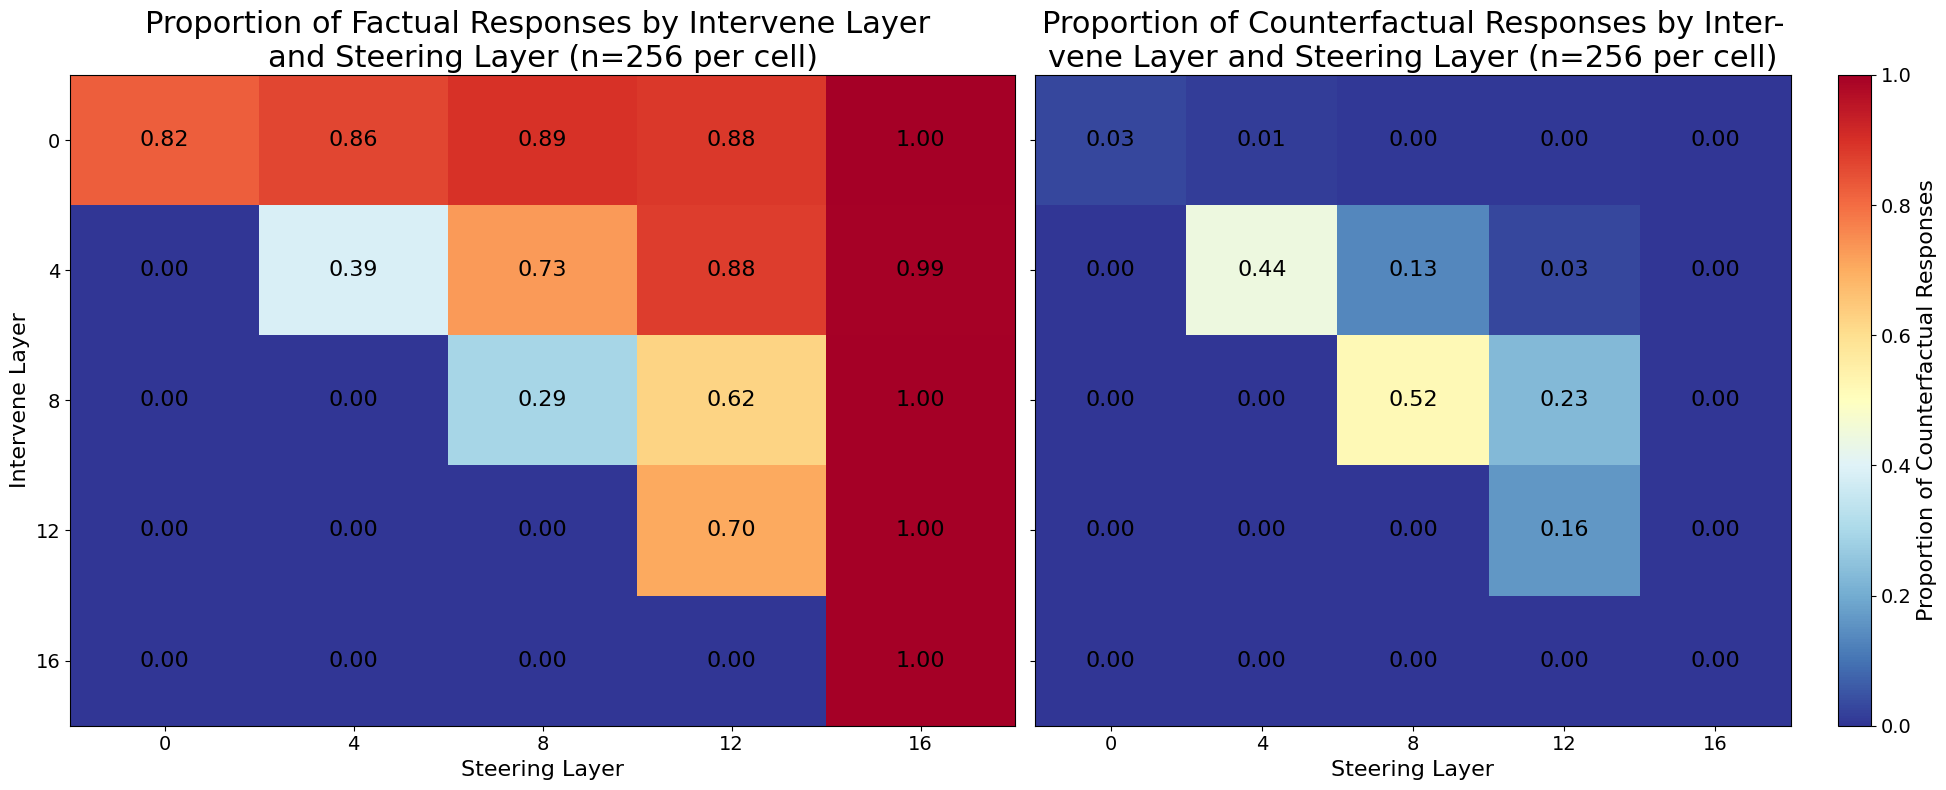

Pivot table (Proportion of factual responses):
steering_layer         0         4         8         12        16
intervene_layer                                                  
0                0.820312  0.859375  0.894531  0.882812  0.996094
4                0.000000  0.386719  0.726562  0.875000  0.992188
8                0.000000  0.000000  0.292969  0.621094  1.000000
12               0.000000  0.000000  0.000000  0.703125  1.000000
16               0.000000  0.000000  0.000000  0.000000  0.996094

Pivot table (Proportion of counterfactual responses):
steering_layer         0         4         8         12   16
intervene_layer                                             
0                0.027344  0.011719  0.003906  0.003906  0.0
4                0.000000  0.441406  0.132812  0.027344  0.0
8                0.000000  0.000000  0.515625  0.226562  0.0
12               0.000000  0.000000  0.000000  0.160156  0.0
16               0.000000  0.000000  0.000000  0.000000  0.0


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the CSV file
df = pd.read_csv("/users/dkang33/arithmetic-reasoning-causality/experiments/activation_intervention/output/GPT-OSS/vanilla_steering/restatement_positive.csv")

# Create pivot tables for both is_factual and is_counterfactual
pivot_table_factual = df.groupby(['intervene_layer', 'steering_layer'])['is_factual'].mean().unstack(fill_value=0)
pivot_table_counterfactual = df.groupby(['intervene_layer', 'steering_layer'])['is_counterfactual'].mean().unstack(fill_value=0)

# Create subplots for both heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

# Factual responses heatmap
im1 = ax1.imshow(pivot_table_factual.values, cmap='RdYlBu_r', aspect='auto', vmin=0, vmax=1)
ax1.set_xticks(range(len(pivot_table_factual.columns)))
ax1.set_xticklabels(pivot_table_factual.columns, fontsize=14)
ax1.set_yticks(range(len(pivot_table_factual.index)))
ax1.set_yticklabels(pivot_table_factual.index, fontsize=14)
ax1.set_xlabel('Steering Layer', fontsize=16)
ax1.set_ylabel('Intervene Layer', fontsize=16)
ax1.set_title('Proportion of Factual Responses by Intervene Layer \nand Steering Layer (n=256 per cell)', fontsize=22)

# Add text annotations for factual
for i in range(len(pivot_table_factual.index)):
    for j in range(len(pivot_table_factual.columns)):
        text = ax1.text(j, i, f'{pivot_table_factual.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=16)

# Add colorbar for factual
# cbar1 = plt.colorbar(im1, ax=ax1)
# cbar1.set_label('Proportion of Factual Responses')

# Counterfactual responses heatmap
im2 = ax2.imshow(pivot_table_counterfactual.values, cmap='RdYlBu_r', aspect='auto', vmin=0, vmax=1)
ax2.set_xticks(range(len(pivot_table_counterfactual.columns)))
ax2.set_xticklabels(pivot_table_counterfactual.columns, fontsize=14)
ax2.set_yticks(range(len(pivot_table_counterfactual.index)))
ax2.set_yticklabels(pivot_table_counterfactual.index, fontsize=14)
ax2.set_xlabel('Steering Layer', fontsize=16)
# ax2.set_ylabel('Intervene Layer', fontsize=16)
ax2.set_title('Proportion of Counterfactual Responses by Inter-\nvene Layer and Steering Layer (n=256 per cell)', fontsize=22)

# Add text annotations for counterfactual
for i in range(len(pivot_table_counterfactual.index)):
    for j in range(len(pivot_table_counterfactual.columns)):
        text = ax2.text(j, i, f'{pivot_table_counterfactual.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=16)

# Add colorbar for counterfactual
cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label('Proportion of Counterfactual Responses', fontsize=16)
cbar2.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.show()

# Print the pivot tables for reference
print("Pivot table (Proportion of factual responses):")
print(pivot_table_factual)
print("\nPivot table (Proportion of counterfactual responses):")
print(pivot_table_counterfactual)


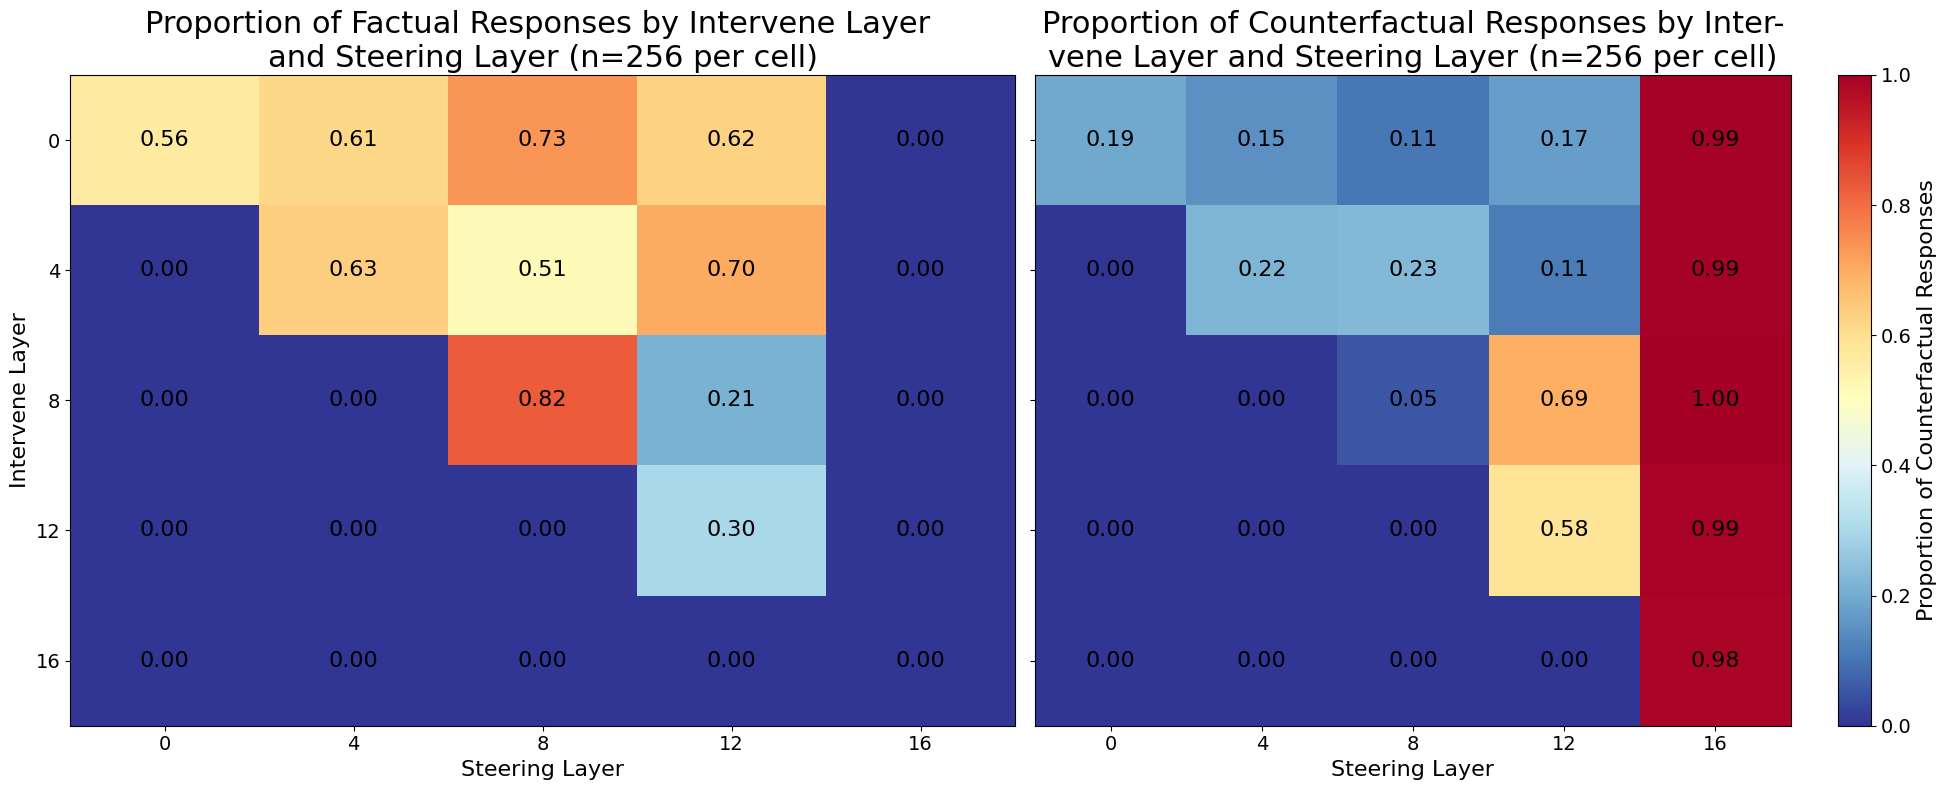

Pivot table (Proportion of factual responses):
steering_layer       0         4         8         12   16
intervene_layer                                           
0                0.5625  0.613281  0.734375  0.625000  0.0
4                0.0000  0.632812  0.511719  0.699219  0.0
8                0.0000  0.000000  0.824219  0.210938  0.0
12               0.0000  0.000000  0.000000  0.296875  0.0
16               0.0000  0.000000  0.000000  0.000000  0.0

Pivot table (Proportion of counterfactual responses):
steering_layer         0         4         8         12        16
intervene_layer                                                  
0                0.191406  0.148438  0.105469  0.171875  0.992188
4                0.000000  0.218750  0.226562  0.113281  0.992188
8                0.000000  0.000000  0.050781  0.691406  0.996094
12               0.000000  0.000000  0.000000  0.582031  0.988281
16               0.000000  0.000000  0.000000  0.000000  0.984375


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the CSV file
df = pd.read_csv("/users/dkang33/arithmetic-reasoning-causality/experiments/activation_intervention/output/GPT-OSS/vanilla_steering/restatement_negative.csv")

# Create pivot tables for both is_factual and is_counterfactual
pivot_table_factual = df.groupby(['intervene_layer', 'steering_layer'])['is_factual'].mean().unstack(fill_value=0)
pivot_table_counterfactual = df.groupby(['intervene_layer', 'steering_layer'])['is_counterfactual'].mean().unstack(fill_value=0)

# Create subplots for both heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

# Factual responses heatmap
im1 = ax1.imshow(pivot_table_factual.values, cmap='RdYlBu_r', aspect='auto', vmin=0, vmax=1)
ax1.set_xticks(range(len(pivot_table_factual.columns)))
ax1.set_xticklabels(pivot_table_factual.columns, fontsize=14)
ax1.set_yticks(range(len(pivot_table_factual.index)))
ax1.set_yticklabels(pivot_table_factual.index, fontsize=14)
ax1.set_xlabel('Steering Layer', fontsize=16)
ax1.set_ylabel('Intervene Layer', fontsize=16)
ax1.set_title('Proportion of Factual Responses by Intervene Layer \nand Steering Layer (n=256 per cell)', fontsize=22)

# Add text annotations for factual
for i in range(len(pivot_table_factual.index)):
    for j in range(len(pivot_table_factual.columns)):
        text = ax1.text(j, i, f'{pivot_table_factual.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=16)

# Add colorbar for factual
# cbar1 = plt.colorbar(im1, ax=ax1)
# cbar1.set_label('Proportion of Factual Responses')

# Counterfactual responses heatmap
im2 = ax2.imshow(pivot_table_counterfactual.values, cmap='RdYlBu_r', aspect='auto', vmin=0, vmax=1)
ax2.set_xticks(range(len(pivot_table_counterfactual.columns)))
ax2.set_xticklabels(pivot_table_counterfactual.columns, fontsize=14)
ax2.set_yticks(range(len(pivot_table_counterfactual.index)))
ax2.set_yticklabels(pivot_table_counterfactual.index, fontsize=14)
ax2.set_xlabel('Steering Layer', fontsize=16)
# ax2.set_ylabel('Intervene Layer', fontsize=16)
ax2.set_title('Proportion of Counterfactual Responses by Inter-\nvene Layer and Steering Layer (n=256 per cell)', fontsize=22)

# Add text annotations for counterfactual
for i in range(len(pivot_table_counterfactual.index)):
    for j in range(len(pivot_table_counterfactual.columns)):
        text = ax2.text(j, i, f'{pivot_table_counterfactual.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=16)

# Add colorbar for counterfactual
cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label('Proportion of Counterfactual Responses', fontsize=16)
cbar2.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.show()

# Print the pivot tables for reference
print("Pivot table (Proportion of factual responses):")
print(pivot_table_factual)
print("\nPivot table (Proportion of counterfactual responses):")
print(pivot_table_counterfactual)


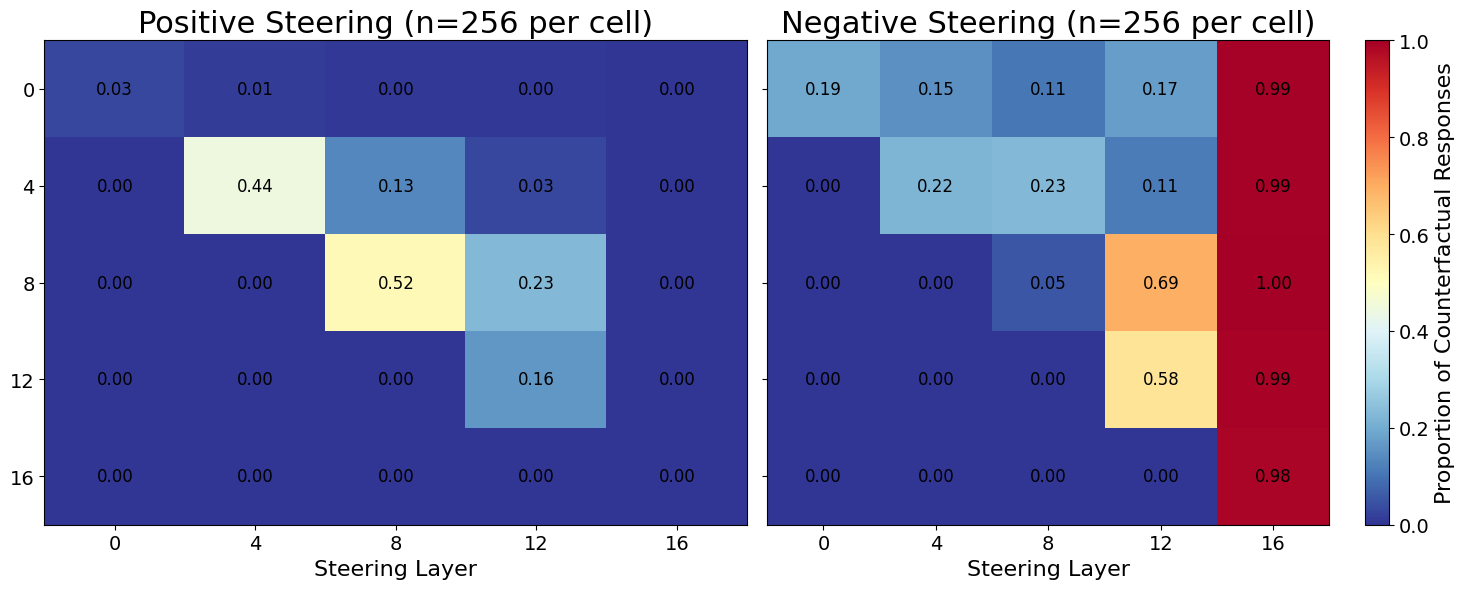

Pivot table (Proportion of factual responses):


NameError: name 'pivot_table_factual' is not defined

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the CSV file
positive_df = pd.read_csv("/users/dkang33/arithmetic-reasoning-causality/experiments/activation_intervention/output/GPT-OSS_stepwise/vanilla_steering/restatement_positive.csv")

# Create pivot tables for both is_factual and is_counterfactual
positive_pivot_table_factual = positive_df.groupby(['intervene_layer', 'steering_layer'])['is_factual'].mean().unstack(fill_value=0)
positive_pivot_table_counterfactual = positive_df.groupby(['intervene_layer', 'steering_layer'])['is_counterfactual'].mean().unstack(fill_value=0)

# Read the CSV file
negative_df = pd.read_csv("/users/dkang33/arithmetic-reasoning-causality/experiments/activation_intervention/output/GPT-OSS_stepwise/vanilla_steering/restatement_negative.csv")

# Create pivot tables for both is_factual and is_counterfactual
negative_pivot_table_factual = negative_df.groupby(['intervene_layer', 'steering_layer'])['is_factual'].mean().unstack(fill_value=0)
negative_pivot_table_counterfactual = negative_df.groupby(['intervene_layer', 'steering_layer'])['is_counterfactual'].mean().unstack(fill_value=0)

# Create subplots for both heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Positive steering responses heatmap
im2 = ax1.imshow(positive_pivot_table_counterfactual.values, cmap='RdYlBu_r', aspect='auto', vmin=0, vmax=1)
ax1.set_xticks(range(len(positive_pivot_table_counterfactual.columns)))
ax1.set_xticklabels(positive_pivot_table_counterfactual.columns, fontsize=14)
ax1.set_yticks(range(len(positive_pivot_table_counterfactual.index)))
ax1.set_yticklabels(positive_pivot_table_counterfactual.index, fontsize=14)
ax1.set_xlabel('Steering Layer', fontsize=16)
# ax1.set_ylabel('Intervene Layer', fontsize=16)
ax1.set_title('Positive Steering (n=256 per cell)', fontsize=22)

# Add text annotations for counterfactual
for i in range(len(positive_pivot_table_counterfactual.index)):
    for j in range(len(positive_pivot_table_counterfactual.columns)):
        text = ax1.text(j, i, f'{positive_pivot_table_counterfactual.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=12)

# Negative steering responses heatmap
im2 = ax2.imshow(negative_pivot_table_counterfactual.values, cmap='RdYlBu_r', aspect='auto', vmin=0, vmax=1)
ax2.set_xticks(range(len(negative_pivot_table_counterfactual.columns)))
ax2.set_xticklabels(negative_pivot_table_counterfactual.columns, fontsize=14)
ax2.set_yticks(range(len(negative_pivot_table_counterfactual.index)))
ax2.set_yticklabels(negative_pivot_table_counterfactual.index, fontsize=14)
ax2.set_xlabel('Steering Layer', fontsize=16)
# ax2.set_ylabel('Intervene Layer', fontsize=16)
ax2.set_title('Negative Steering (n=256 per cell)', fontsize=22)

# Add text annotations for counterfactual
for i in range(len(negative_pivot_table_counterfactual.index)):
    for j in range(len(negative_pivot_table_counterfactual.columns)):
        text = ax2.text(j, i, f'{negative_pivot_table_counterfactual.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=12)

# Add colorbar for counterfactual
cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label('Proportion of Counterfactual Responses', fontsize=16)
cbar2.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.show()

# Print the pivot tables for reference
print("Pivot table (Proportion of factual responses):")
print(pivot_table_factual)
print("\nPivot table (Proportion of counterfactual responses):")
print(pivot_table_counterfactual)
